# pH evaluation

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from roms_tools import Grid, ROMSOutput
from plot import (
    _add_coastlines_and_gridlines,
    _plot_colorbar,
    compute_zoom_box,
    get_label_string,
    zoom_box_indices,
    ZOOM_COORDS,
)

## Time series

In [2]:
# One color per release site (used for the truth curves in plot_pH_curves; the
# surface-field maps use colormaps, not these).
SITE_COLORS = {
    "JP": "#df65b0",  # pink
    "VI": "#4CAF50",  # green
    "BC": "#2196F3",  # blue
    "EC": "#FFA500",  # orange
}

_SITE_LETTER = {"JP": "J", "VI": "V", "BC": "B", "EC": "E"}
_AMP_LABEL = {"10": "10", "7": "100", "8": "1000"}


def _make_exps(sign):
    """{f'{site}{amp}': {color, label}} for every site x amplitude. `sign` is the
    trailing math token, e.g. r'\\!\\ominus' (DOR) or r'\\oplus' (OAE)."""
    return {
        f"{site}{amp}": {
            "color": SITE_COLORS[site],
            "label": rf"$\mathrm{{{_SITE_LETTER[site]}{lab}}}{sign}$",
        }
        for site in SITE_COLORS
        for amp, lab in _AMP_LABEL.items()
    }


EXPS_DOR = _make_exps(r"\!\ominus")
EXPS_OAE = _make_exps(r"\oplus")

# Per-scenario data layout. `dor` is fully computed; `oae` is a template -- its
# CDR-tracer pH (roms/exp0/OUTPUT_oae/pH/) and MAX_PH still need to be produced:
#   compute_pH.py --exp 0 --mode oae --year <YYYY>
#   compute_max_ph_cdr_tracer.py --exp 0 --mode oae --year <YYYY>
SCENARIOS = {
    "dor": {
        "exps": EXPS_DOR,
        "truth_dir": "roms_marbl_dic",   # ROMS-MARBL truth runs (PH, PH_ALT_CO2)
        "cdr_subdir": "OUTPUT_dor",       # roms/exp0/<cdr_subdir>/{pH,MAX_PH}
        "amp8_suffix": "",                # truth amp-1000 site-dir suffix
    },
    "oae": {
        "exps": EXPS_OAE,
        "truth_dir": "roms_marbl_alk",
        "cdr_subdir": "OUTPUT_oae",
        "amp8_suffix": "",     
    },
}

In [3]:
def load_cdr(scenario="dor", id=0):
    """Spatial-max CDR-tracer surface-pH time series for a scenario ("dor" | "oae").

    Precomputed by roms/workflows/compute_max_ph_cdr_tracer.py from the daily
    full-domain pH reconstruction. Has, per experiment, `max_ph_<exp>` and
    `max_delta_ph_<exp>` (= max of pH_<exp> - pH_ctrl), plus `max_ph_ctrl`.
    """
    subdir = SCENARIOS[scenario]["cdr_subdir"]
    return xr.open_mfdataset(
        f"roms/exp{id}/{subdir}/MAX_PH/max_ph_*.nc", combine="by_coords"
    )


def load_marbl(scenario="dor"):
    """Spatial-max truth surface-pH time series for a scenario ("dor" | "oae").

    From roms_marbl_*/workflows/compute_max_ph.py. amp-1000 truth runs may carry
    a site-dir suffix (SCENARIOS[scenario]["amp8_suffix"]).
    """
    scen = SCENARIOS[scenario]
    data = {}
    for exp in scen["exps"]:
        suffix = scen["amp8_suffix"] if exp[2:] == "8" else ""
        ds = xr.open_mfdataset(
            f"{scen['truth_dir']}/exp{exp}{suffix}/OUTPUT/MAX_PH/max_ph_*.nc"
        )
        data[exp] = ds
    return data

In [4]:
def _math(label):
    """Strip outer $ signs for embedding in a larger math expression."""
    return label.strip("$")

In [5]:
BACKGROUND_COLOR = "#f5f5f5"

# One line style per site, cycled in `exp_pref_list` order, for the black
# CDR-tracer estimate curves.
CDR_LINESTYLES = ["dashed", "solid", "dotted", "dashdot"]


def plot_pH_curves(ax, exp_pref_list, amps, marbl_data, exps, ds_cdr=None,
                   legend_below=True, delta=True, vline=None, panel_label="a"):
    """Spatial-max surface pH vs time for a set of experiments.

    Colored line: truth (ROMS-MARBL), one fixed color per site (the mid-amplitude
    shade, so panels for different amplitudes share the same palette).
    Black line: CDR-tracer estimate (only when `ds_cdr` is given), one line style
    per site. `delta=True` plots max (pH - pH_alt_co2), `delta=False` plots max pH.
    `vline` (a date string, or None) draws a vertical dashed reference line.
    """
    varname = "max_delta_ph" if delta else "max_ph"

    for i, exp_pref in enumerate(exp_pref_list):
        color = exps[f"{exp_pref}7"]["color"]          # fixed per-site (mid amplitude)
        cdr_ls = CDR_LINESTYLES[i % len(CDR_LINESTYLES)]
        for amp in amps:
            exp = f"{exp_pref}{amp}"

            # CDR-tracer estimate
            if ds_cdr is not None:
                cdr_var = f"max_delta_ph_{exp}" if delta else f"max_ph_{exp}"
                ax.plot(
                    ds_cdr.time,
                    ds_cdr[cdr_var],
                    color="k",
                    label=rf"{exps[exp]['label']} (CDR tracer)",
                    linewidth=3,
                    linestyle=cdr_ls,
                )
                
            # truth
            ds = marbl_data[exp]
            ax.plot(
                ds.time,
                ds[varname],
                color=color,
                label=rf"{exps[exp]['label']} (truth)",
                linewidth=2,
            )

    if vline is not None:
        ax.axvline(np.datetime64(vline), color="0.35", linestyle="--",
                   linewidth=1.2, zorder=0)

    ax.margins(x=0.01)                  # trim the empty time axis beyond the data
    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    if delta:
        ax.set_title(rf"({panel_label}) max($\delta$pH)")
    else:
        ax.set_title(rf"({panel_label}) max(pH)")
    ax.grid()

    # Reorder legend: all CDR tracer entries first, then all truth entries,
    # so the two groups each occupy their own column(s).
    handles, labels = ax.get_legend_handles_labels()
    cdr_pairs  = [(h, l) for h, l in zip(handles, labels) if "(CDR tracer)" in l]
    truth_pairs = [(h, l) for h, l in zip(handles, labels) if "(truth)" in l]
    h_ord, l_ord = zip(*(cdr_pairs + truth_pairs)) if (cdr_pairs or truth_pairs) else ([], [])

    ncol = max(1, len(exp_pref_list) // 2)
    if legend_below:
        ax.legend(h_ord, l_ord, loc="upper center", bbox_to_anchor=(0.5, -0.15),
                  fontsize=10, ncol=ncol, handlelength=3,
                  facecolor=BACKGROUND_COLOR)
    else:
        ax.legend(h_ord, l_ord, loc="lower right", ncol=ncol,
                  handlelength=3, facecolor=BACKGROUND_COLOR)
    ax.patch.set_facecolor(BACKGROUND_COLOR)

In [6]:
def plot_error_curves(ax, exp_pref_list, amps, marbl_data, exps, ds_cdr,
                      legend_below=True, vline=None, panel_label="a"):
    """Timeseries of max(delta_pH) error: CDR tracer minus truth.

    One colored line per site (same palette as `plot_pH_curves`). Call once per
    panel; pass a single-element `amps` list for one amplitude per panel.
    """
    for i, exp_pref in enumerate(exp_pref_list):
        color = exps[f"{exp_pref}7"]["color"]
        for amp in amps:
            exp = f"{exp_pref}{amp}"
            error = ds_cdr[f"max_delta_ph_{exp}"] - marbl_data[exp]["max_delta_ph"]
            ax.plot(
                error.time,
                error,
                color=color,
                label=exps[exp]["label"],
                linewidth=2,
            )

    ax.axhline(0, color="0.4", linewidth=0.8, linestyle="--", zorder=0)
    if vline is not None:
        ax.axvline(np.datetime64(vline), color="0.35", linestyle="--",
                   linewidth=1.2, zorder=0)

    ax.margins(x=0.01)
    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    ax.set_title(rf"({panel_label}) max($\delta$pH) error (CDR tracer $-$ truth)")
    ax.grid()

    handles, labels = ax.get_legend_handles_labels()
    ncol = max(1, len(exp_pref_list) // 2)
    if legend_below:
        ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.15),
                  fontsize=10, ncol=ncol, handlelength=3,
                  facecolor=BACKGROUND_COLOR)
    else:
        ax.legend(handles, labels, loc="lower right", ncol=ncol,
                  handlelength=3, facecolor=BACKGROUND_COLOR)
    ax.patch.set_facecolor(BACKGROUND_COLOR)

In [7]:
def select_nearest_point(lon_pt, lat_pt):
    """Return (eta, xi) indices of the nearest ocean grid point to (lon_pt, lat_pt)."""
    lon_rho = grid.ds["lon_rho"]
    lat_rho = grid.ds["lat_rho"]
    mask = grid.ds["mask_rho"].astype(bool)
    dist = ((lon_rho - lon_pt) ** 2 + (lat_rho - lat_pt) ** 2).where(mask)
    idx = np.unravel_index(int(dist.fillna(np.inf).argmin()), dist.shape)
    eta, xi = idx
    return eta, xi, float(lon_rho[eta, xi]), float(lat_rho[eta, xi])


def load_point_cdr(lon_pt, lat_pt, scenario="dor", id=0):
    """CDR-tracer pH and delta-pH time series at the grid point nearest to (lon_pt, lat_pt).

    Returns (ds_pt, actual_lon, actual_lat). ds_pt has variables pH_ctrl,
    pH_<exp>, and delta_ph_<exp> = pH_<exp> - pH_ctrl for every experiment
    present in the monthly pH files.
    """
    subdir = SCENARIOS[scenario]["cdr_subdir"]
    ds = xr.open_mfdataset(
        f"roms/exp{id}/{subdir}/pH/pH_*.nc", combine="by_coords"
    )
    eta, xi, alon, alat = select_nearest_point(lon_pt, lat_pt)
    ds_pt = ds.isel(eta_rho=eta, xi_rho=xi)
    # add delta_ph convenience variables
    ctrl = ds_pt["pH_ctrl"]
    for v in ds_pt.data_vars:
        if v.startswith("pH_") and v != "pH_ctrl":
            exp = v[len("pH_"):]
            ds_pt[f"delta_ph_{exp}"] = ds_pt[v] - ctrl
    return ds_pt, alon, alat


def load_point_marbl(lon_pt, lat_pt, exp, scenario="dor"):
    """ROMS-MARBL truth pH and delta-pH time series at the grid point nearest to (lon_pt, lat_pt).

    Loads PH and PH_ALT_CO2 from the bgc_dia files for `exp` (e.g. "JP10").
    Returns (ds_pt, actual_lon, actual_lat).
    """
    scen = SCENARIOS[scenario]
    suffix = scen["amp8_suffix"] if exp[2:] == "8" else ""
    roms_output = ROMSOutput(
        grid=grid,
        path=f"{scen['truth_dir']}/exp{exp}{suffix}/OUTPUT/JOINED/pacmed_bgc_dia.*.nc",
        use_dask=True,
    )
    ds = roms_output.ds
    eta, xi, alon, alat = select_nearest_point(lon_pt, lat_pt)
    ds_pt = ds[["PH", "PH_ALT_CO2"]].isel(s_rho=-1, eta_rho=eta, xi_rho=xi)
    ds_pt["delta_ph"] = ds_pt["PH"] - ds_pt["PH_ALT_CO2"]
    return ds_pt, alon, alat


def plot_pH_point_timeseries(lon_pt, lat_pt, exp_pref_list, amps, scenario="dor",
                             id=0, show_truth=True, figsize=(12, 6)):
    """Two-panel (pH on top, ΔpH on bottom) time series at the grid point nearest (lon_pt, lat_pt).

    Colored lines are ROMS-MARBL truth; black lines (one style per site) are
    CDR-tracer reconstructions. Set `show_truth=False` to skip loading truth data.
    """
    exps_dict = SCENARIOS[scenario]["exps"]
    ds_cdr, alon, alat = load_point_cdr(lon_pt, lat_pt, scenario=scenario, id=id)

    fig, (ax_ph, ax_dph) = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(
        rf"Point time series at ({alon:.2f}°E, {alat:.2f}°N)  "
        rf"[requested: ({lon_pt:.2f}°E, {lat_pt:.2f}°N)]",
        fontsize=11,
    )

    for i, exp_pref in enumerate(exp_pref_list):
        color = exps_dict[f"{exp_pref}7"]["color"]
        cdr_ls = CDR_LINESTYLES[i % len(CDR_LINESTYLES)]

        for amp in amps:
            exp = f"{exp_pref}{amp}"
            label = exps_dict[exp]["label"]

            # CDR-tracer
            if f"pH_{exp}" in ds_cdr:
                ax_ph.plot(ds_cdr.time, ds_cdr[f"pH_{exp}"],
                           color="k", linestyle=cdr_ls, linewidth=2,
                           label=rf"{label} CDR")
                ax_dph.plot(ds_cdr.time, ds_cdr[f"delta_ph_{exp}"],
                            color="k", linestyle=cdr_ls, linewidth=2,
                            label=rf"{label} CDR")

            # ROMS-MARBL truth
            if show_truth:
                ds_t, _, _ = load_point_marbl(lon_pt, lat_pt, exp, scenario=scenario)
                ax_ph.plot(ds_t.time, ds_t["PH"].compute(),
                           color=color, linewidth=1.5, label=rf"{label} truth")
                ax_dph.plot(ds_t.time, ds_t["delta_ph"].compute(),
                            color=color, linewidth=1.5, label=rf"{label} truth")

    # CDR ctrl pH
    ax_ph.plot(ds_cdr.time, ds_cdr["pH_ctrl"], color="0.4", linewidth=1.5,
               linestyle="solid", label="ctrl (CDR)")

    for ax, ylabel in [(ax_ph, "pH"), (ax_dph, r"$\delta$pH")]:
        ax.set_ylabel(ylabel)
        ax.grid()
        ax.patch.set_facecolor(BACKGROUND_COLOR)
        ncol = max(1, len(exp_pref_list) // 2)
        ax.legend(loc="upper left", ncol=ncol, fontsize=9, handlelength=3,
                  facecolor=BACKGROUND_COLOR)

    ax_dph.axhline(0, color="0.4", linewidth=0.8, linestyle="--", zorder=0)
    ax_dph.set_xlabel("Time")
    plt.tight_layout()
    return fig

### DOR

In [17]:
marbl_dic = load_marbl("dor")
cdr_dic = load_cdr("dor")

#### max pH

In [18]:
exp_pref_list = ["JP"]

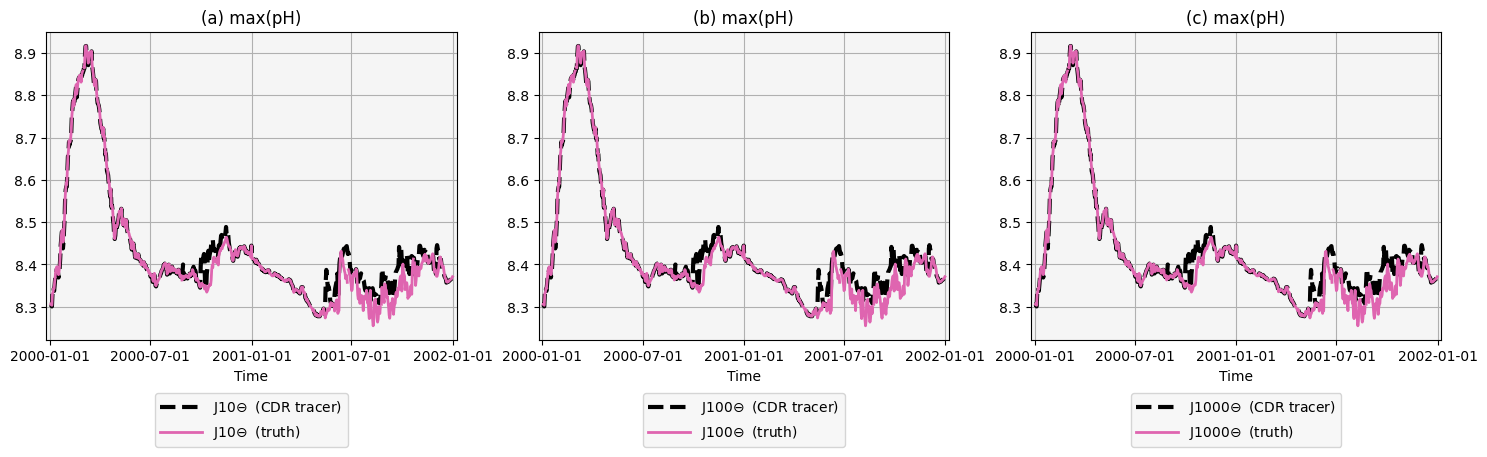

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_pH_curves(axs[0], exp_pref_list=exp_pref_list, amps=[10], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="a")
plot_pH_curves(axs[1], exp_pref_list=exp_pref_list, amps=[7], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="b")
plot_pH_curves(axs[2], exp_pref_list=exp_pref_list, amps=[8], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="c")
fig.subplots_adjust(hspace=0.3)

In [20]:
exp_pref_list = ["VI"]

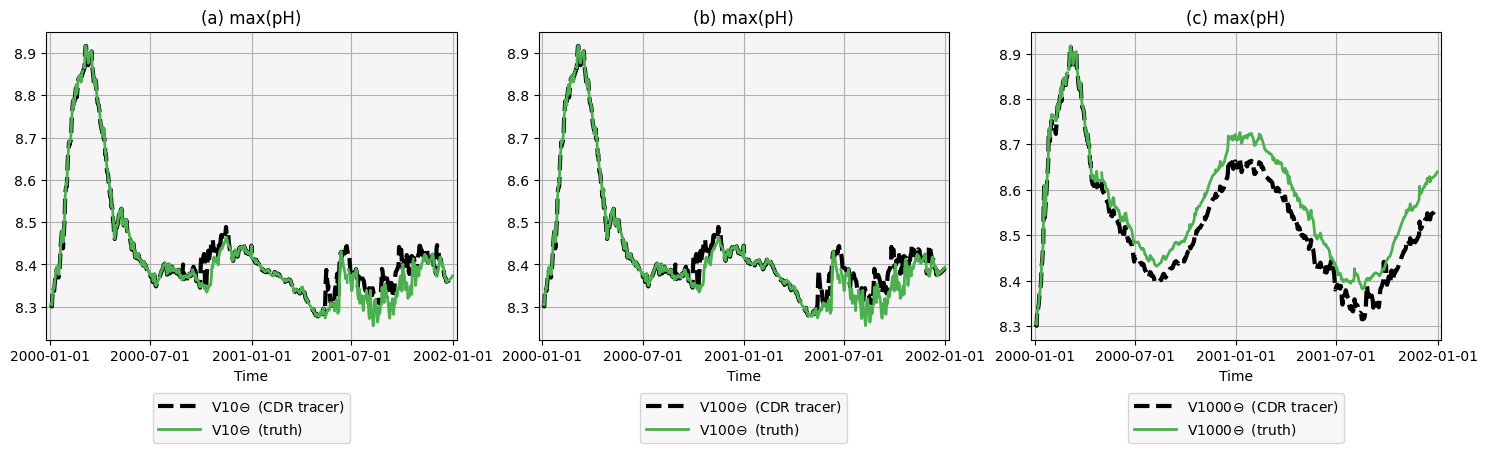

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_pH_curves(axs[0], exp_pref_list=exp_pref_list, amps=[10], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="a")
plot_pH_curves(axs[1], exp_pref_list=exp_pref_list, amps=[7], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="b")
plot_pH_curves(axs[2], exp_pref_list=exp_pref_list, amps=[8], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="c")
fig.subplots_adjust(hspace=0.3)

In [22]:
exp_pref_list = ["BC"]

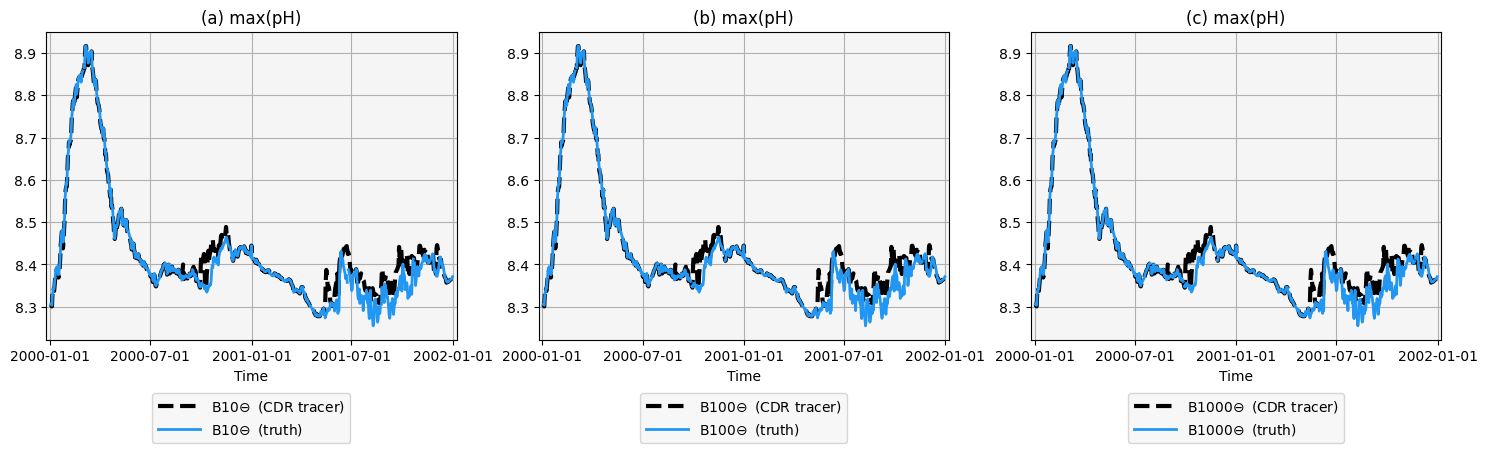

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_pH_curves(axs[0], exp_pref_list=exp_pref_list, amps=[10], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="a")
plot_pH_curves(axs[1], exp_pref_list=exp_pref_list, amps=[7], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="b")
plot_pH_curves(axs[2], exp_pref_list=exp_pref_list, amps=[8], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="c")
fig.subplots_adjust(hspace=0.3)

In [24]:
exp_pref_list = ["EC"]

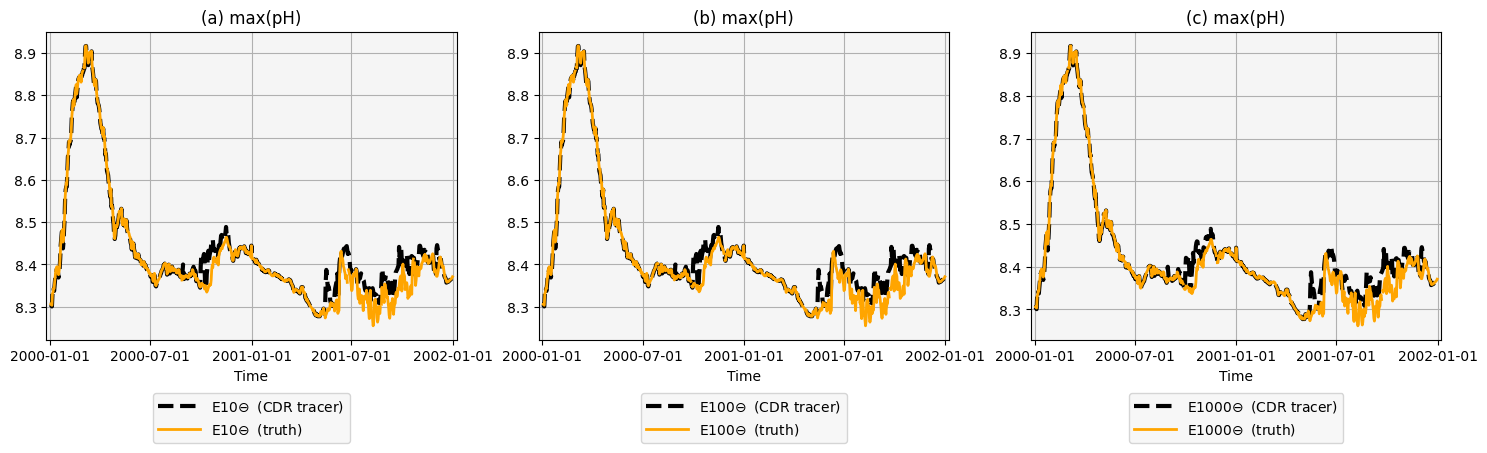

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_pH_curves(axs[0], exp_pref_list=exp_pref_list, amps=[10], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="a")
plot_pH_curves(axs[1], exp_pref_list=exp_pref_list, amps=[7], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="b")
plot_pH_curves(axs[2], exp_pref_list=exp_pref_list, amps=[8], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, delta=False, panel_label="c")
fig.subplots_adjust(hspace=0.3)

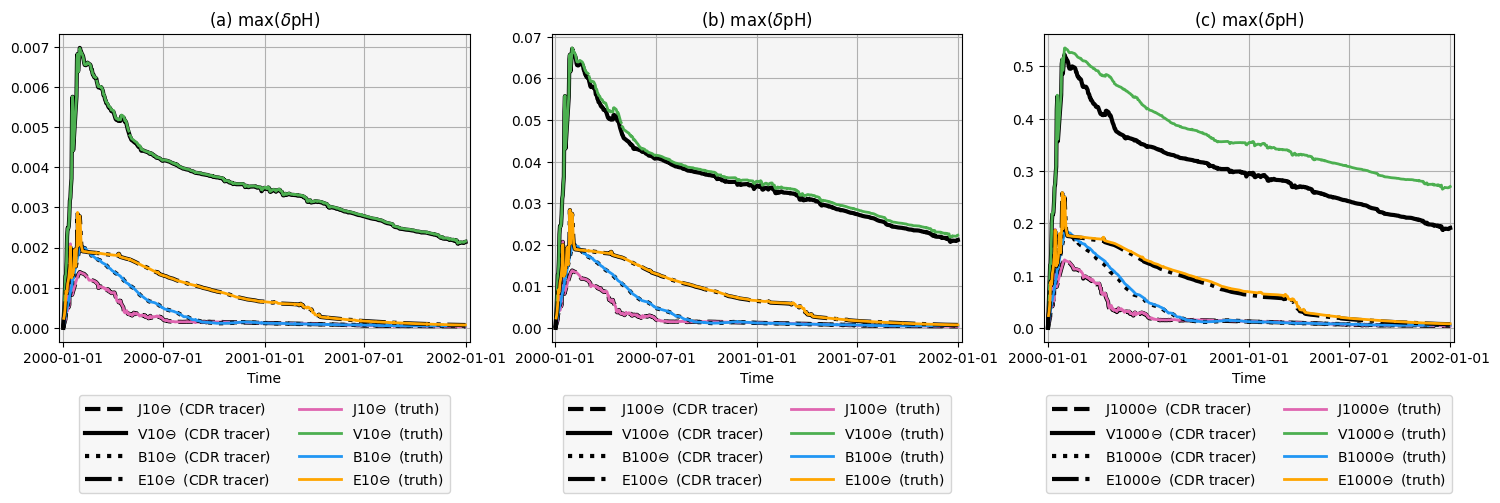

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_pH_curves(axs[0], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[10], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, panel_label="a")
plot_pH_curves(axs[1], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[7], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, panel_label="b")
plot_pH_curves(axs[2], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[8], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, panel_label="c")
fig.subplots_adjust(hspace=0.3)

In [63]:
fig.savefig(
    "figures/max_delta_pH_dor.png",
    dpi=300,
    bbox_inches="tight",
)

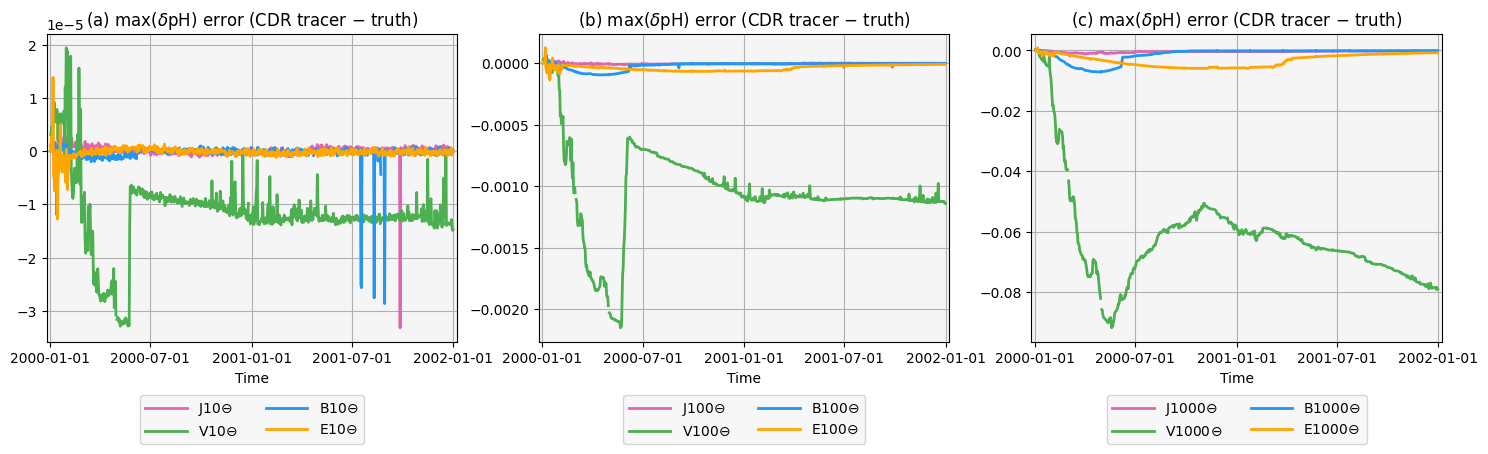

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_error_curves(axs[0], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[10], marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, panel_label="a")
plot_error_curves(axs[1], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[7],  marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, panel_label="b")
plot_error_curves(axs[2], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[8],  marbl_data=marbl_dic, exps=EXPS_DOR, ds_cdr=cdr_dic, panel_label="c")
fig.subplots_adjust(hspace=0.3)

### OAE

In [8]:
marbl_oae = load_marbl("oae")
cdr_oae = load_cdr("oae")

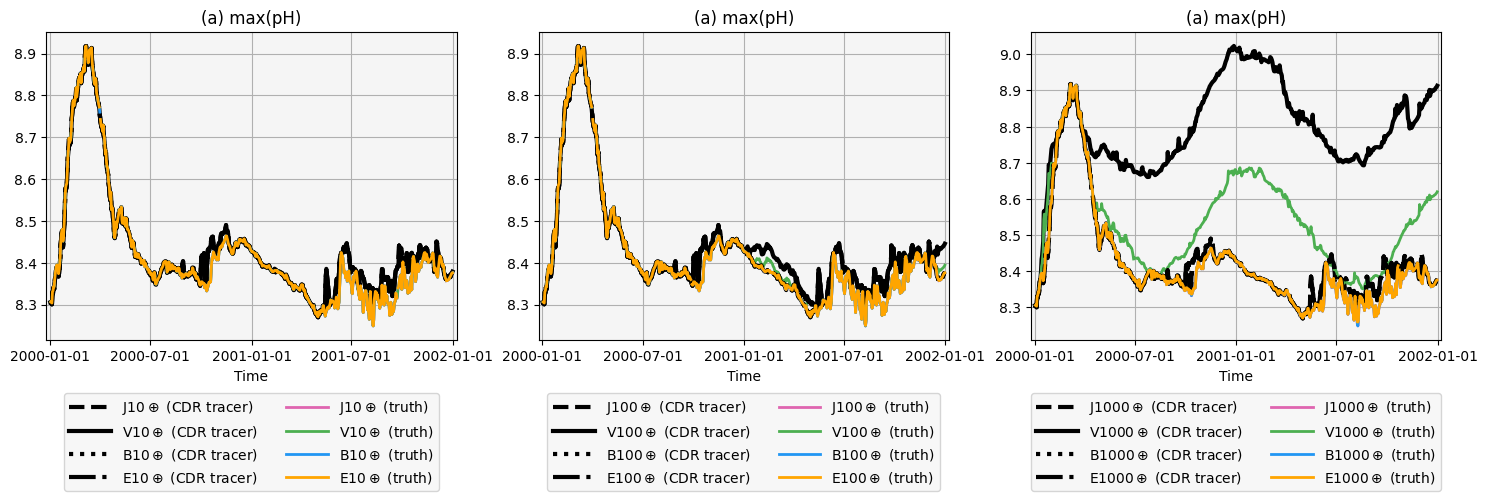

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_pH_curves(axs[0], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[10], marbl_data=marbl_oae, exps=EXPS_OAE, ds_cdr=cdr_oae, delta=False)
plot_pH_curves(axs[1], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[7],  marbl_data=marbl_oae, exps=EXPS_OAE, ds_cdr=cdr_oae, delta=False)
plot_pH_curves(axs[2], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[8],  marbl_data=marbl_oae, exps=EXPS_OAE, ds_cdr=cdr_oae, delta=False)
fig.subplots_adjust(hspace=0.3)

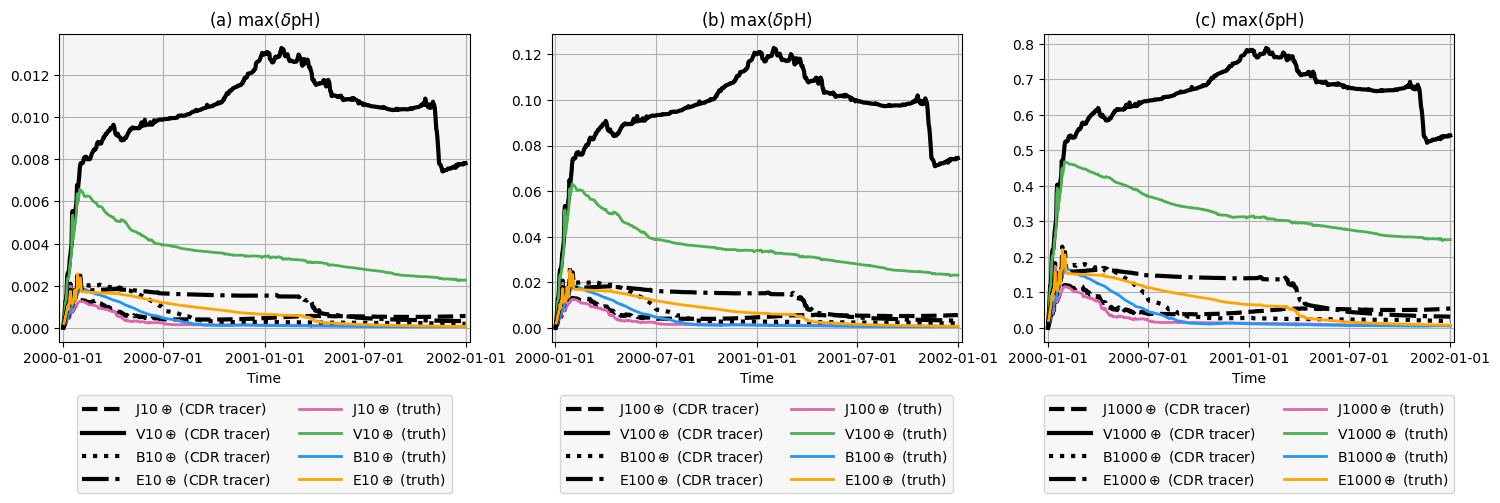

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
plot_pH_curves(axs[0], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[10], marbl_data=marbl_oae, exps=EXPS_OAE, ds_cdr=cdr_oae, panel_label="a")
plot_pH_curves(axs[1], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[7], marbl_data=marbl_oae, exps=EXPS_OAE, ds_cdr=cdr_oae, panel_label="b")
plot_pH_curves(axs[2], exp_pref_list=["JP", "VI", "BC", "EC"], amps=[8], marbl_data=marbl_oae, exps=EXPS_OAE, ds_cdr=cdr_oae, panel_label="c")
fig.subplots_adjust(hspace=0.3)

In [ ]:
fig.savefig(
    "figures/max_delta_pH_oae.png",
    dpi=300,
    bbox_inches="tight",
)

## Surface fields

Surface $\delta$pH on a single day: **truth** ($\mathrm{PH} - \mathrm{PH\_ALT\_CO2}$ from
the ROMS-MARBL runs) vs. the **CDR-tracer reconstruction**
($\mathrm{pH}_{\text{exp}} - \mathrm{pH}_{\text{ctrl}}$, from
`roms/exp0/OUTPUT_dor/pH/`, built by `roms/workflows/compute_pH.py`).

Each figure is 1$\times$2: $\delta$pH (truth) on the left, error (CDR tracer $-$ truth)
on the right. Same structure as `deltaDIC_deltaALK.ipynb`.

In [10]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-09-02 05:08:49 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-09-02 05:08:49 - INFO - Total time: 0.003 seconds
2026-09-02 05:08:49 - INFO - ================================================================================================


In [11]:
def zoom_box(lon_min=None, lon_max=None, lat_min=None, lat_max=None,
             center=None, half_width_km=None):
    """A zoom box for the surface-field maps.

    Either pass an explicit lon/lat box, or `center=(lon, lat)` plus
    `half_width_km` for a square of that half-width around the point.
    """
    if center is not None:
        lon_min, lon_max, lat_min, lat_max = compute_zoom_box(center, half_width_km)
    return {"lon_min": lon_min, "lon_max": lon_max,
            "lat_min": lat_min, "lat_max": lat_max}


locations = {
    "JP": {"name": "Japan",            "zoom_coords": ZOOM_COORDS["JP"]},
    "VI": {"name": "Vancouver Island", "zoom_coords": ZOOM_COORDS["VI"]},
    "BC": {"name": "Baja California",  "zoom_coords": ZOOM_COORDS["BC"]},
    "EC": {"name": "Ecuador",          "zoom_coords": ZOOM_COORDS["EC"]},
}

amp_labels = {"10": "10", "7": "100", "8": "1000"}

# To zoom the surface-field maps in tighter, see the "Closer zoom-ins" cell below.

In [18]:
def load_surface_dpH(date, scenario, loc_keys=None, amps=("10", "7", "8")):
    """Surface fields for one day: CDR-tracer pH reconstruction + truth output.

    `scenario` is "dor" or "oae" (see SCENARIOS). Returns (cdr_ds, truth_data):
      * cdr_ds     - the daily pH file for that month, selected to `date`. The
                     CDR-tracer delta-pH for an experiment is
                     cdr_ds[f"pH_{exp}"] - cdr_ds["pH_ctrl"].
      * truth_data - {exp: ROMS-MARBL bgc_dia dataset}; truth delta-pH is
                     PH - PH_ALT_CO2.

    `date` is "YYYYMMDD".
    """
    scen = SCENARIOS[scenario]
    if loc_keys is None:
        loc_keys = list(locations)

    day = np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:8]}")
    cdr_ds = xr.open_dataset(
        f"roms/exp0/{scen['cdr_subdir']}/pH/pH_{date[:6]}.nc"
    ).sel(time=day, method="nearest")

    truth_data = {}
    for loc in loc_keys:
        for amp in amps:
            exp = f"{loc}{amp}"
            suffix = scen["amp8_suffix"] if amp == "8" else ""
            roms_output = ROMSOutput(
                grid=grid,
                path=f"{scen['truth_dir']}/exp{exp}{suffix}/OUTPUT/JOINED/pacmed_bgc_dia.{date}*.nc",
                use_dask=True,
            )
            truth_data[exp] = roms_output.ds
    return cdr_ds, truth_data

### Core functions

In [13]:
def compute_dpH(cdr_ds, truth_data, exp):
    """Surface delta-pH (truth, CDR-tracer reconstruction) for one experiment."""
    ds = truth_data[exp]
    truth = (ds["PH"] - ds["PH_ALT_CO2"]).squeeze().compute()
    recon = (cdr_ds[f"pH_{exp}"] - cdr_ds["pH_ctrl"]).squeeze().compute()
    return truth, recon


def field_kwargs(*fields, cmap="PuRd"):
    """Sequential 0..max colorbar shared across `fields` (delta-pH >= 0 for DOR)."""
    vmax = max(float(np.abs(f).max(skipna=True)) for f in fields) or 1.0
    return {"vmin": 0.0, "vmax": vmax, "cmap": cmap}


def diff_kwargs(diff, cmap="RdBu_r"):
    """Diverging colorbar symmetric about zero."""
    vmax = float(np.abs(diff).max(skipna=True)) or 1.0
    return {"vmin": -vmax, "vmax": vmax, "cmap": cmap}


def _sci_str(x, digits=2):
    """'$1.20\\times10^{-3}$' mathtext for a scalar (nice for annotations)."""
    if not np.isfinite(x) or x == 0:
        return "$0$"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / 10 ** exp
    return rf"${mant:.{digits}f}\times10^{{{exp}}}$"


def _mag_label(da):
    """'Max magnitude = $m\\times10^{n}$' annotation string."""
    return f"Max magnitude = {_sci_str(float(np.abs(da).max(skipna=True)))}"


def _sci_formatter(cbar, nbins=4):
    """Give a colorbar ~`nbins` ticks with a shared x10^n exponent (not '1e-4')."""
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 2))
    cbar.locator = MaxNLocator(nbins)
    cbar.formatter = fmt
    cbar.update_ticks()

In [14]:
def plot_dpH_truth_error(cdr_ds, truth_data, loc_key, amp, exps=EXPS_DOR,
                         kwargs_field=None, kwargs_diff=None,
                         figsize=(11, 4.5), shrink=0.85, pad=0.1,
                         panel_labels=("a", "b")):
    """1x2 panel for one experiment: surface delta-pH (truth) | error (CDR tracer - truth).

    `exps` is EXPS_DOR or EXPS_OAE (for the panel labels). Truth colorbar is
    clipped at 0 (no left extend arrow); the error colorbar auto-extends. Both
    use x10^n scientific tick labels.
    """
    exp = f"{loc_key}{amp}"
    zoom = locations[loc_key]["zoom_coords"]
    proj = ccrs.LambertConformal(
        central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
        central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
    )

    truth, recon = compute_dpH(cdr_ds, truth_data, exp)
    error = recon - truth

    kf = kwargs_field or field_kwargs(truth)
    kd = kwargs_diff or diff_kwargs(error)

    label = exps[exp]["label"]
    titles = (
        rf"{label}: $\delta$pH (truth)",
        rf"{label}: $\delta$pH error (CDR tracer $-$ truth)",
    )
    # truth: clip at 0, only grow an arrow on the high side; error: auto
    clip0 = "max" if float(truth.max(skipna=True)) > kf["vmax"] else "neither"
    extends = (clip0, None)

    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]
    mask = grid.ds.mask_rho

    fig, axs = plt.subplots(1, 2, figsize=figsize, subplot_kw={"projection": proj})
    for ax, data, kw, base, ext, plab in zip(
        axs, (truth, error), (kf, kd), titles, extends, panel_labels
    ):
        p = ax.pcolormesh(lon, lat, data.where(mask),
                          transform=ccrs.PlateCarree(), **kw)
        cbar = _plot_colorbar(fig, ax, p, data, kw.get("vmax"), kw.get("vmin"),
                              label="pH", shrink=shrink, pad=pad, extend=ext)
        _sci_formatter(cbar)
        ax.text(0.5, 0.04, _mag_label(data), transform=ax.transAxes,
                ha="center", va="center")
        ax.set_title(f"({plab}) {base}" if plab else base)
        _add_coastlines_and_gridlines(
            ax, zoom["lon_min"], zoom["lon_max"], zoom["lat_min"], zoom["lat_max"])

    plt.tight_layout()
    return fig


# sign key -> (test, latex symbol, extremum reducer, extremum label, word)
_SIGN_SEL = {
    "neg": (lambda d: d < 0, "< 0", lambda d: d.min(skipna=True), "min", "negative"),
    "pos": (lambda d: d > 0, "> 0", lambda d: d.max(skipna=True), "max", "positive"),
}


def plot_dpH_negative(cdr_ds, truth_data, loc_key, amp, exps=EXPS_DOR,
                      signs=("neg", "pos"), cmaps=("Blues", "Reds"), pct=98,
                      vmaxes=(None, None), figsize=(11, 4.5), shrink=0.85,
                      pad=0.12, panel_labels=("a", "b")):
    """1x2 map: |surface delta-pH| restricted to one sign per panel, linear colorbar.

    `exps` is EXPS_DOR or EXPS_OAE (for the panel labels). `signs` picks the sign
    shown in each panel ("neg" -> where delta-pH < 0, "pos" -> where > 0). Default
    ("neg", "pos"): truth delta-pH < 0 on the left, error > 0 (CDR tracer
    over-predicts) on the right. Each panel shows |delta-pH| there, 0..vmax, where
    vmax defaults to the `pct`-th percentile of the in-view (zoom-box) selected
    magnitudes (so one coastal outlier doesn't set the whole scale); override per
    panel with `vmaxes=(left, right)`. The sign is in the title; the annotation
    gives the fraction of in-view ocean cells and the signed extreme in-view
    value. `cmaps` are the (neg, pos) colormaps.
    """
    exp = f"{loc_key}{amp}"
    zoom = locations[loc_key]["zoom_coords"]
    proj = ccrs.LambertConformal(
        central_longitude=(zoom["lon_min"] + zoom["lon_max"]) / 2,
        central_latitude=(zoom["lat_min"] + zoom["lat_max"]) / 2,
    )

    truth, recon = compute_dpH(cdr_ds, truth_data, exp)
    error = recon - truth

    eta_sl, xi_sl = zoom_box_indices(grid, loc_key, zoom_coords={loc_key: zoom})
    lon, lat = grid.ds["lon_rho"], grid.ds["lat_rho"]
    mask = grid.ds.mask_rho.astype(bool)
    n_ocean_z = int(mask.isel(eta_rho=eta_sl, xi_rho=xi_sl).sum())
    cmap_by_sign = {"neg": cmaps[0], "pos": cmaps[1]}

    label = exps[exp]["label"]
    panels = [
        (truth, signs[0], "", "truth", vmaxes[0]),
        (error, signs[1], "error ", "CDR tracer $-$ truth", vmaxes[1]),
    ]

    fig, axs = plt.subplots(1, 2, figsize=figsize, subplot_kw={"projection": proj})
    for ax, (data, sign, err_word, kind, vmax_override), plab in zip(axs, panels, panel_labels):
        test, sym, extremum, ext_label, word = _SIGN_SEL[sign]

        hit = test(data) & mask
        data_z = data.isel(eta_rho=eta_sl, xi_rho=xi_sl).where(hit.isel(eta_rho=eta_sl, xi_rho=xi_sl))
        n_hit = int(np.isfinite(data_z).sum())

        mag = np.abs(data).where(hit)
        if n_hit:
            vmax = vmax_override or float(np.abs(data_z).quantile(pct / 100, skipna=True))
            note = (f"{100 * n_hit / n_ocean_z:.1f}% of cells in view;  "
                    f"{ext_label} = {_sci_str(float(extremum(data_z)), 1)}")
        else:
            vmax = vmax_override or 1e-3
            note = f"no {word} values in view"

        p = ax.pcolormesh(lon, lat, mag.where(mask), transform=ccrs.PlateCarree(),
                          vmin=0.0, vmax=vmax, cmap=cmap_by_sign[sign])
        cbar = fig.colorbar(p, ax=ax, orientation="horizontal", shrink=shrink,
                            pad=pad, extend="max", label=r"$|\delta \mathrm{pH}|$")
        _sci_formatter(cbar)

        ax.text(0.5, 0.04, note, transform=ax.transAxes, ha="center", va="center",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5))
        base = rf"{label}: $\delta$pH {err_word}{sym} ({kind})"
        ax.set_title(f"({plab}) {base}" if plab else base)
        _add_coastlines_and_gridlines(
            ax, zoom["lon_min"], zoom["lon_max"], zoom["lat_min"], zoom["lat_max"])

    plt.tight_layout()
    return fig

### $\delta$pH: DOR

#### July 1, 2000

In [19]:
date = "20000701"
cdr_ds, truth_data = load_surface_dpH(date, scenario="dor", amps=("8",))

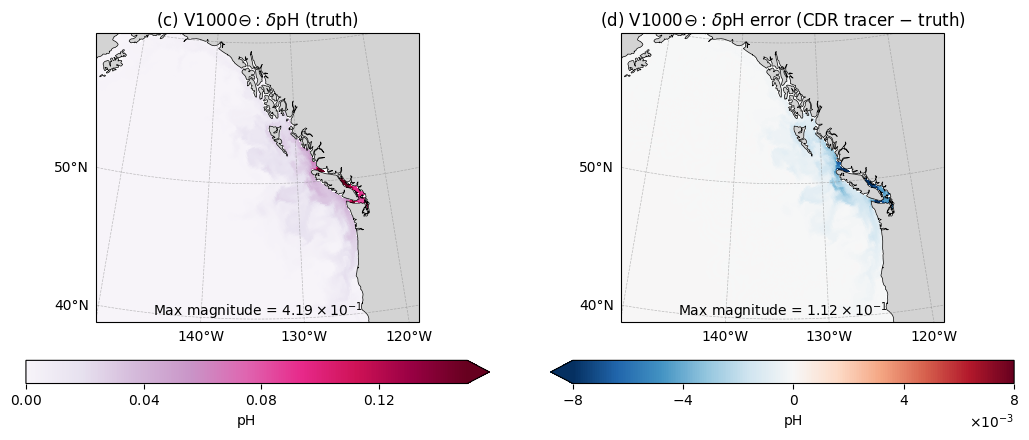

In [20]:
kwargs_field = {"vmin": 0, "vmax": 0.15, "cmap": "PuRd"}
kwargs_diff = {"vmin": -0.008, "vmax": 0.008, "cmap": "RdBu_r"}

fig = plot_dpH_truth_error(cdr_ds, truth_data, "VI", "8", kwargs_field=kwargs_field, kwargs_diff=kwargs_diff, panel_labels=("c", "d"))
fig.savefig(f"figures/dpH_dor_V1000_{date}.png", dpi=300, bbox_inches="tight")

In [21]:
date = "20000201"
cdr_ds, truth_data = load_surface_dpH(date, scenario="dor", amps=("8",))

In [22]:
locations["JP"]["zoom_coords"] = zoom_box(center=(142, 36), half_width_km=1000)

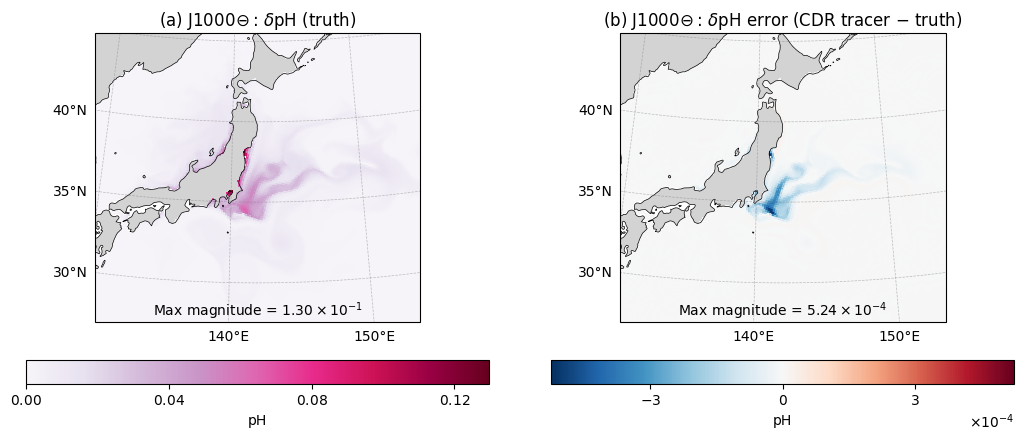

In [23]:
fig = plot_dpH_truth_error(cdr_ds, truth_data, "JP", "8", panel_labels=("a", "b"))
fig.savefig(f"figures/dpH_dor_J1000_{date}.png", dpi=300, bbox_inches="tight")

In [199]:
locations["VI"]["zoom_coords"] = zoom_box(center=(-130, 50), half_width_km=700)

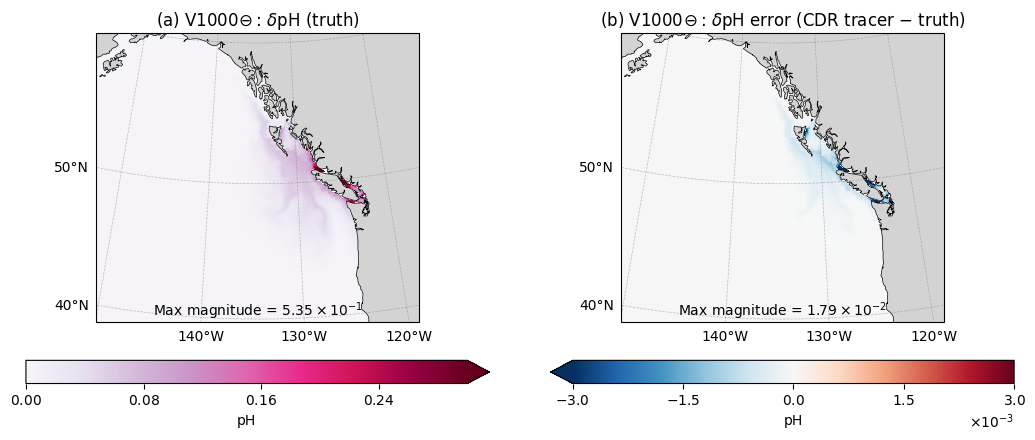

In [24]:
kwargs_field = {"vmin": 0, "vmax": 0.3, "cmap": "PuRd"}
kwargs_diff = {"vmin": -0.003, "vmax": 0.003, "cmap": "RdBu_r"}

fig = plot_dpH_truth_error(cdr_ds, truth_data, "VI", "8", kwargs_field=kwargs_field, kwargs_diff=kwargs_diff, panel_labels=("a", "b"))
fig.savefig(f"figures/dpH_dor_V1000_{date}.png", dpi=300, bbox_inches="tight")

In [25]:
locations["BC"]["zoom_coords"] = zoom_box(center=(-115, 27), half_width_km=1000)

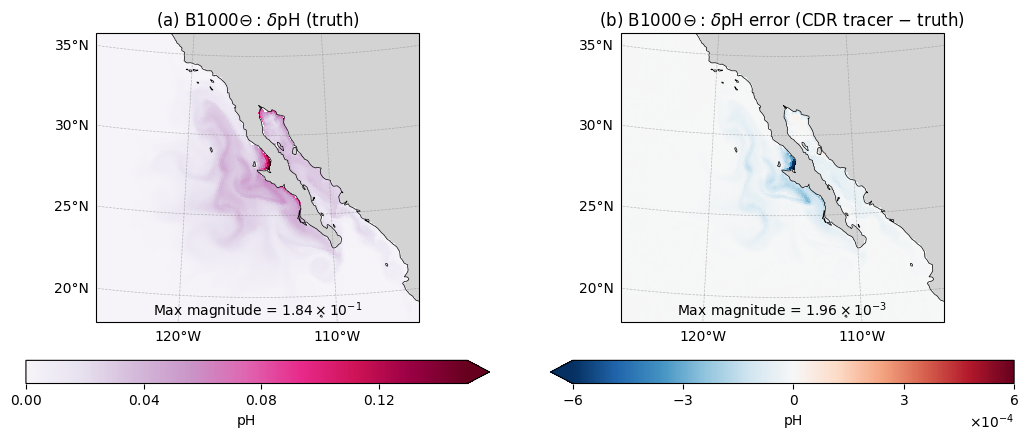

In [26]:
kwargs_field = {"vmin": 0, "vmax": 0.15, "cmap": "PuRd"}
kwargs_diff = {"vmin": -0.0006, "vmax": 0.0006, "cmap": "RdBu_r"}

fig = plot_dpH_truth_error(cdr_ds, truth_data, "BC", "8", kwargs_field=kwargs_field, kwargs_diff=kwargs_diff, panel_labels=("a", "b"))
fig.savefig(f"figures/dpH_dor_B1000_{date}.png", dpi=300, bbox_inches="tight")

In [27]:
locations["EC"]["zoom_coords"] = zoom_box(center=(-83, 0), half_width_km=1000)

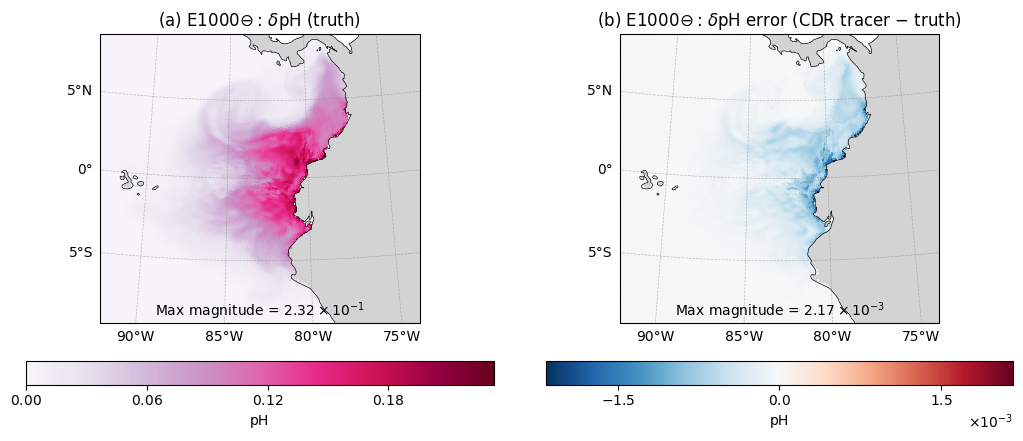

In [28]:
fig = plot_dpH_truth_error(cdr_ds, truth_data, "EC", "8", panel_labels=("a", "b"))
fig.savefig(f"figures/dpH_dor_E1000_{date}.png", dpi=300, bbox_inches="tight")

### Sign of $\delta$pH

For each site (amp 1000): left = truth $\delta$pH where it is **negative**, right =
the error (CDR tracer $-$ truth) where it is **positive** (CDR over-predicts $\delta$pH).
Each panel shows $|\delta\mathrm{pH}|$ there on a linear colorbar, $0\ldots$ the 98th
percentile of the in-view magnitudes (`pct` arg; override per panel with `vmaxes`).
The sign is in the title; the annotation gives the fraction of in-view ocean cells and
the signed extreme value. Pass `signs=("neg", "neg")` etc. to change which sign a panel shows.

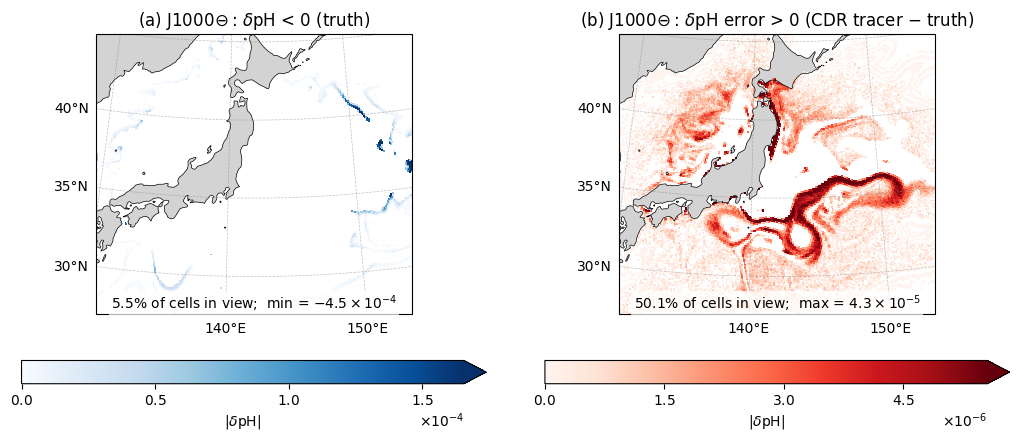

In [215]:
fig = plot_dpH_negative(cdr_ds, truth_data, "JP", "8", panel_labels=("a", "b"))

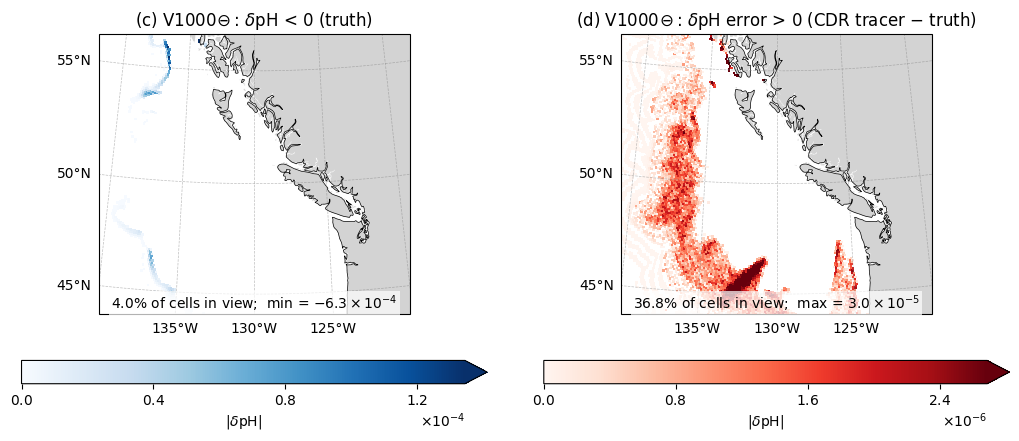

In [216]:
fig = plot_dpH_negative(cdr_ds, truth_data, "VI", "8", panel_labels=("c", "d"))

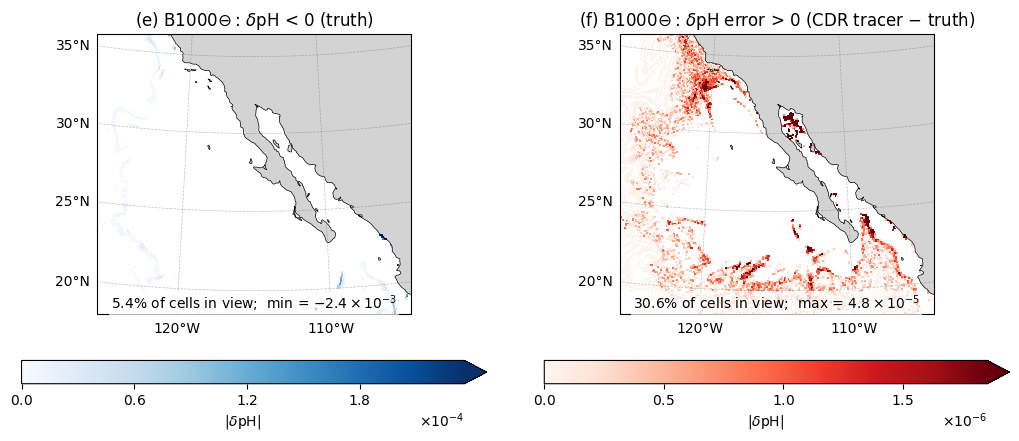

In [217]:
fig = plot_dpH_negative(cdr_ds, truth_data, "BC", "8", panel_labels=("e", "f"))

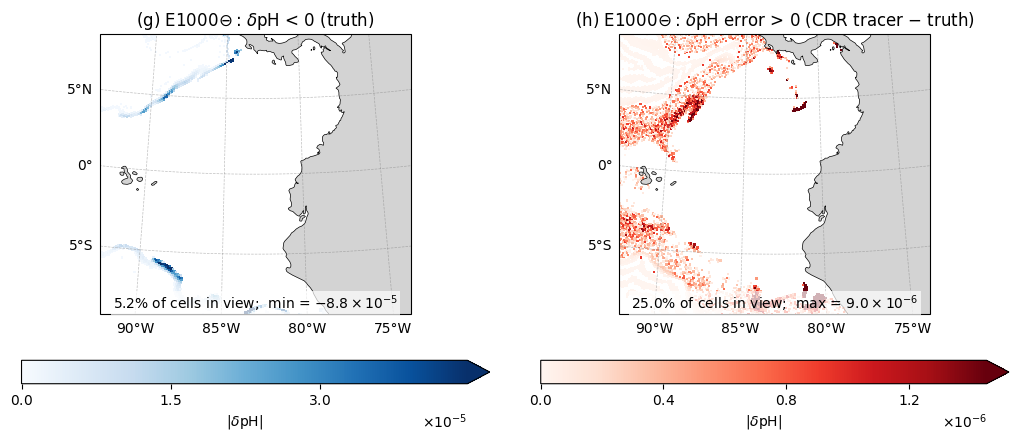

In [218]:
fig = plot_dpH_negative(cdr_ds, truth_data, "EC", "8", panel_labels=("g", "h"))

### OAE

Same plots for the OAE scenario: `load_surface_dpH(..., scenario="oae")` and pass
`exps=EXPS_OAE` to the plot functions. Needs `roms/exp0/OUTPUT_oae/pH/` (from
`compute_pH.py --mode oae`); the `roms_marbl_alk` truth is already there.

In [ ]:
date_oae = "20000701"
cdr_ds_oae, truth_data_oae = load_surface_dpH(date_oae, scenario="oae", amps=("8",))

In [ ]:
fig = plot_dpH_truth_error(cdr_ds_oae, truth_data_oae, "JP", "8", exps=EXPS_OAE)
# fig.savefig("figures/dpH_oae_J1000.png", dpi=300, bbox_inches="tight")

fig = plot_dpH_negative(cdr_ds_oae, truth_data_oae, "JP", "8", exps=EXPS_OAE)
# fig.savefig("figures/dpH_oae_negative_J1000.png", dpi=300, bbox_inches="tight")